### 1. Problem Statement

We prepare the dataset for a product recommendation system using user ratings.

This stage focuses on:
- cleaning the dataset
- understanding user and product interaction patterns
- converting data into a user-item matrix suitable for collaborative filtering

### 2. Import Libraries

In [2]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings
import warnings
warnings.filterwarnings('ignore')

### 3. Load Dataset

In [3]:
# load dataset
df = pd.read_csv("rating_short.csv")

# preview data
df.head()

,userid,productid,rating,date
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,1199750400
1,ALDXDYEGKB27G,B002L6HE9G,4.0,1331337600
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,1358640000
3,A23LX12CA3G4FG,B008HOEDYU,1.0,1385337600
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1402963200


In [4]:
# check column names explicitly
df.columns

Index(['userid', 'productid', 'rating', 'date'], dtype='object')

We verify the column names before performing any operations to avoid errors.


### 4. Basic Checks

In [5]:
# shape
df.shape

# info
df.info()

# missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78245 entries, 0 to 78244
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userid     78245 non-null  object 
 1   productid  78245 non-null  object 
 2   rating     78245 non-null  float64
 3   date       78245 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 2.4+ MB


userid       0
productid    0
rating       0
date         0
dtype: int64

The dataset does not contain missing values, so no imputation is required.

In [6]:
# summary stats
df.describe()

,rating,date
count,78245.000000,7.824500e+04
mean,4.006454,1.338128e+09
std,1.385342,6.891994e+07
min,1.000000,9.320832e+08
25%,3.000000,1.315008e+09
50%,5.000000,1.360800e+09
75%,5.000000,1.386029e+09
max,5.000000,1.406074e+09


### 5. Drop Timestamp

In [7]:
# drop date column (time not needed for CF)
df.drop('date', axis=1, inplace=True)

The timestamp column is not required for collaborative filtering, since recommendations are based on user-item interactions.

### 6. Remove Duplicates

In [8]:
# check duplicate rows
df.duplicated().sum()

np.int64(0)

### 7. Exploratory Data Analysis

#### 7.1 Rating Distribution

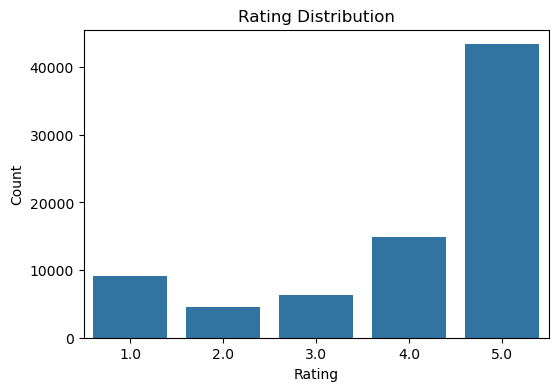

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Ratings are mostly concentrated at higher values, indicating users generally give positive feedback.

#### 7.2 Ratings per Product

In [10]:
# number of ratings per product
ratings_per_product = df.groupby('productid')['rating'].count()
print(ratings_per_product)

productid
0594481813    1
0972683275    7
0983947600    1
1400501466    1
1400501776    1
             ..
B00KYMCJF8    1
B00KZ40HT0    1
B00L1LXOWS    1
B00L26IGP2    1
B00L2EZ60C    1
Name: rating, Length: 40228, dtype: int64


In [11]:
# summary statistics
ratings_per_product.describe()

count    40228.000000
mean         1.945038
std          3.766158
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        201.000000
Name: rating, dtype: float64

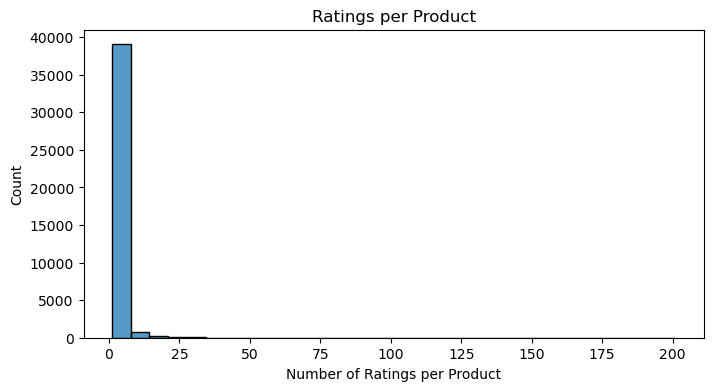

In [12]:
# histogram of ratings per product
plt.figure(figsize=(8,4))
sns.histplot(ratings_per_product, bins=30)
plt.title("Ratings per Product")
plt.xlabel("Number of Ratings per Product")
plt.ylabel("Count")
plt.show()

Most products receive very few ratings, while a small number receive more.  
This imbalance contributes to sparsity in the dataset.

#### 7.3 Ratings per User

In [13]:
# number of ratings per user
ratings_per_user = df.groupby('userid')['rating'].count()
            
# summary statistics
ratings_per_user.describe()

count    76430.000000
mean         1.023747
std          0.177128
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: rating, dtype: float64

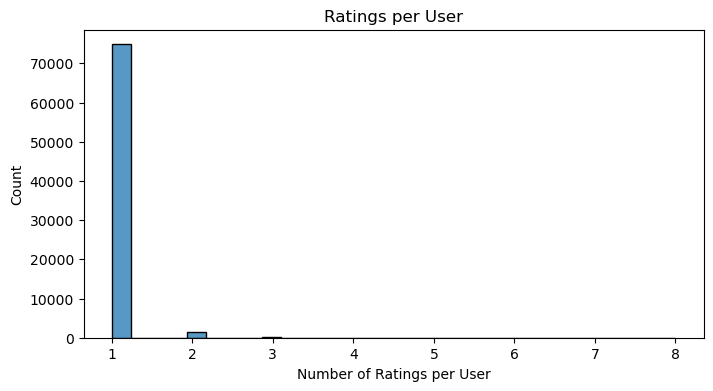

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(ratings_per_user, bins=30)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Count")
plt.show()

User activity is uneven. Most users have very few interactions, while a smaller group is more active.

### 8. Filtering Low Interactions

In [15]:
# define thresholds
min_user_ratings = 2
min_product_ratings = 2

# count ratings per user
user_counts = df['userid'].value_counts()

# keep users with sufficient interactions
df = df[df['userid'].isin(user_counts[user_counts >= min_user_ratings].index)]
    
# count ratings per product
product_counts = df['productid'].value_counts()

# keep products with sufficient interactions
df = df[df['productid'].isin(product_counts[product_counts >= min_product_ratings].index)]

In [16]:
# check dataset after filtering
df.shape
df['userid'].nunique()
df['productid'].nunique()

246

Users and products with very few interactions are removed.

A minimum threshold of 2 is used to retain enough data while removing cases where similarity cannot be meaningfully computed.

### 9. User-Item Matrix

In [17]:
# create matrix with users as rows and products as columns
user_item_matrix = df.pivot_table(
    index='userid',
    columns='productid',
    values='rating'
)

# check matrix
user_item_matrix.shape
user_item_matrix.head()

productid,B0000635UX,B00006HQR8,B00006JPDI,B00007E7JU,B00007M1TZ,B000204SWE,B00020S7XK,B0002GRL7M,B0002KVQBA,B0002L5R78,...,B00E055H5O,B00E3W15P0,B00EN27TCI,B00EVVGAC6,B00F9ZQQ8Q,B00FNPD1OY,B00GR3FMXE,B00HPM1G8Q,B00INNP5VU,B00JC5Y6YA
userid,,,,,,,,,,,,,,,,,,,,,
A10AFVU66A79Y1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10FRGQSF4E5KE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
A10X7TP9E3OB1A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A117GU6HR5DHER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A11CAZ1CEJGLT4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset is transformed into a matrix where rows represent users and columns represent products.

This format is required for collaborative filtering methods.

### 10. Handle Missing Values

In [18]:
# fill missing values with 0 (no interaction)
user_item_matrix_filled = user_item_matrix.fillna(0)

Missing values indicate that a user has not rated a product.

These are replaced with 0 to allow similarity calculations.

### 11. Sparsity Check

In [19]:
# number of users and products
num_users = user_item_matrix.shape[0]   #0=User
num_items = user_item_matrix.shape[1]   #1=Product

# total possible interactions if every user has rated every product
total_possible_ratings = num_users * num_items

# actual interactions
actual = df.shape[0]

# avoid division error
if total_possible_ratings == 0:
    print("Matrix is empty. Adjust filtering thresholds.")
else:
    sparsity = 1 - (actual / total_possible_ratings)
    print("Sparsity:", sparsity)

Sparsity: 0.9953982161180835


The sparsity value is high, meaning most user-product pairs have no interaction.

This is typical in recommendation systems and influences model design.

### 12. Save Processed Data

In [20]:
# save cleaned dataset
df.to_csv("cleaned_data.csv", index=False)

# save user-item matrix
user_item_matrix_filled.to_csv("user_item_matrix.csv")

## Phase 2 - Model Building and evaluation

In [21]:
#1: Fill Missing Values
user_item_matrix = user_item_matrix.apply(lambda row: row.fillna(row.mean()), axis=1)

In [22]:
#2: Handle Edge Case
user_item_matrix = user_item_matrix.fillna(0)

In [23]:
print(user_item_matrix.isnull().sum().sum())

0


In [24]:
#3: Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
user_item_matrix_filled = scaler.fit_transform(user_item_matrix)

K-MEANS CLUSTERING

In [25]:
#K-means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(user_item_matrix_filled)

print(kmeans_labels[:10])

[1 2 1 1 2 1 0 1 1 0]


In [26]:
#Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(user_item_matrix_filled, kmeans_labels)
print("Silhouette Score:", score)

Silhouette Score: 0.8446240983817609


In [27]:
#HyperParameter tuning
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(user_item_matrix_filled)
    score = silhouette_score(user_item_matrix_filled, labels)
    print(f"K={k}, Score={score}")

K=2, Score=0.7787920169717935
K=3, Score=0.8446240983817609
K=4, Score=0.9062927853307949
K=5, Score=0.9403827175889816
K=6, Score=0.9618972756541927


In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(user_item_matrix_filled)

user_item_matrix['KMeans'] = kmeans_labels

In [29]:
k_score = silhouette_score(user_item_matrix_filled, kmeans_labels)
print("Silhouette Score:", k_score)

Silhouette Score: 0.9062927853307949


In [30]:
#Model Evaluation
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [31]:
#Prediction Function
def predict_rating(user_id, product_id):
    
    if user_id not in user_item_matrix.index:
        return 0
        
    cluster_id = user_item_matrix.loc[user_id, 'KMeans']
    
    cluster_users = user_item_matrix[user_item_matrix['KMeans'] == cluster_id]
    
    if product_id in cluster_users.columns:
        return cluster_users[product_id].mean()
    else:
        return 0
    
#Find users similar to the given user → see what they rated that product → return their average as the prediction.

In [32]:
#RMSE Calculation
from sklearn.metrics import root_mean_squared_error
import numpy as np

y_true, y_pred = [], []

for row in test.itertuples():
    pred = predict_rating(row.userid, row.productid)
    y_true.append(row.rating)
    y_pred.append(pred)

rmse = (root_mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

RMSE: 0.31359467558647347


HIERARCHICAL CLUSTERING

In [33]:
from sklearn.cluster import AgglomerativeClustering

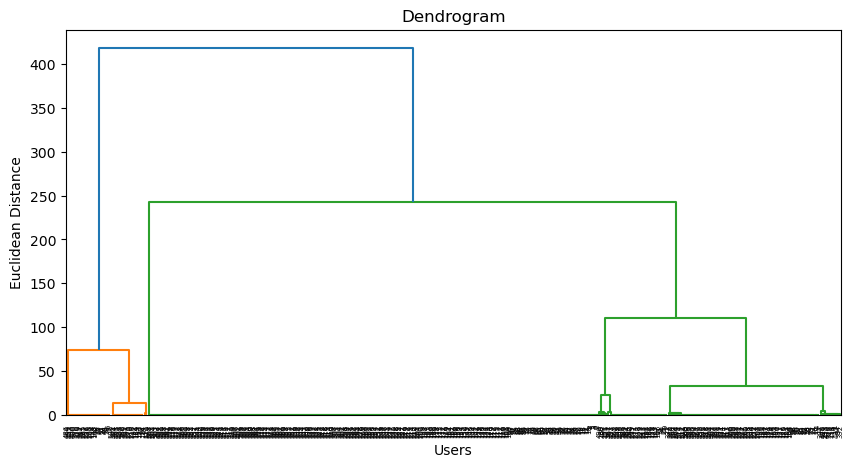

In [34]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

#Dendogram to decide how many clusters we want
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(user_item_matrix_filled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Users")
plt.ylabel("Euclidean Distance")
plt.show()

In [35]:
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hc = hc.fit_predict(user_item_matrix_filled)

In [36]:
labels_hc

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,

In [37]:
#Model Evaluation
from sklearn.metrics import silhouette_score

score_hc = silhouette_score(user_item_matrix_filled, labels_hc)
print("Hierarchical Silhouette Score:", score_hc)

Hierarchical Silhouette Score: 0.7593802919180314


In [38]:
#Comparing both
print("K- Means Silhouette Score:", k_score)
print("Hierarchical Silhouette Score:", score_hc)   

K- Means Silhouette Score: 0.9062927853307949
Hierarchical Silhouette Score: 0.7593802919180314


#### K-Means achieved a high Silhouette Score (~0.90) and a very low RMSE (0.31), indicating strong user segmentation and highly accurate recommendations. Therefore, K-Means is selected as the optimal model for this recommendation system.

Hierarchical clustering helped visualize the cluster structure using a dendrogram, while K-Means performed better in scalability and slightly better silhouette score

In [39]:
#Saving the model
import joblib

joblib.dump(kmeans, "kmeans.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
#Load
kmeans = joblib.load("kmeans.pkl")
scaler = joblib.load("scaler.pkl")